<a href="https://colab.research.google.com/github/SebastianGustavoRojasPeralta/SIS420RojasPeraltaSebastian/blob/main/Laboratorios/Laboratorio04/NoGrafico/Laboratorio04ClasificacionDatasetNoGrafico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laboratorio 04: Clasificación One vs All para dataset no grafico**

Nombre: Sebastian Gustavo Rojas Peralta

Dataset: Online News Popularity



**Preparación y procesamiento de Datos**

En esta sección importamos el dataset utilizando la librería Pandas. Se elimina columnas redundantes como id y label (ya que usaremos attack_cat para nuestra clasificación multiclase). Además, se convierten las variables categóricas de texto a valores numéricos para que el modelo matemático pueda procesarlas sin errores.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

url = '/content/drive/MyDrive/machine learning/datsets/UNSW_NB15_training-set.csv'
df = pd.read_csv(url)

#Eliminar columnas que no sirven para el modelo multiclase
df = df.drop(['id', 'label'], axis=1)

#Convertir variables categóricas (texto) a números usando factorize de Pandas
columnas_texto = ['proto', 'service', 'state']
for col in columnas_texto:
    df[col] = pd.factorize(df[col])[0]

print("Forma del dataset original:", df.shape)

Forma del dataset original: (82332, 43)


**Balanceo del Dataset**

Para garantizar que el modelo no genere sesgos hacia las clases mayoritarias, se aplica una técnica de balanceo. Se fija una cantidad exacta de muestras (6,000) por cada clase. Si una clase tiene más ejemplos, se aplica submuestreo; si tiene menos, se aplica sobremuestreo. Así obtenemos un dataset final de 60,000 ejemplos, cumpliendo la condición de $m \ge 50,000$ y garantizando un balance total.

In [3]:
# Fijamos la cantidad de ejemplos que queremos por cada clase (10 clases x 6000 = 60,000)
muestras_por_clase = 6000

# Agrupamos por tipo de ataque y aplicamos sample
df_balanceado = df.groupby('attack_cat').sample(n=muestras_por_clase, replace=True, random_state=42)

# Desordenamos el dataset para que las clases no estén en bloque
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

# Convertimos nuestras 10 etiquetas de texto a números (del 0 al 9)
df_balanceado['attack_cat'], etiquetas_unicas = pd.factorize(df_balanceado['attack_cat'])

print("Distribución después del balanceo (Ejemplos por clase):")
print(df_balanceado['attack_cat'].value_counts())
print("\nTamaño total del dataset balanceado:", df_balanceado.shape)

Distribución después del balanceo (Ejemplos por clase):
attack_cat
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

Tamaño total del dataset balanceado: (60000, 43)


**División y Normalización (80% Entrenamiento, 20% Prueba)**


Separamos las variables independientes ($X$) de nuestra variable objetivo ($y$). Luego dividimos matemáticamente los datos garantizando que el modelo entrene con el 80% y valide su efectividad con el 20% restante que jamás ha visto. Finalmente, se normalizan (estandarizan) las características de $X$ para que todas tengan la misma escala y el Descenso de Gradiente converja de manera eficiente.

In [4]:
# Separar X e y
X = df_balanceado.drop('attack_cat', axis=1).values
y = df_balanceado['attack_cat'].values

m = len(y)
# Calcular el índice de corte para el 80%
limite = int(m * 0.8)

# División 80/20
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función manual para Normalizar (Estandarización)
def normalizar(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitar divisiones por cero si hay columnas constantes
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos usando solo los datos de entrenamiento
X_train_norm, mu, sigma = normalizar(X_train)
# Aplicamos la MISMA escala a los datos de prueba
X_test_norm = (X_test - mu) / sigma

# Agregar la columna de unos (Termino de sesgo/Intercepto) a ambos conjuntos
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print("Datos de entrenamiento listos:", X_train_norm.shape)
print("Datos de prueba listos:", X_test_norm.shape)

Datos de entrenamiento listos: (48000, 43)
Datos de prueba listos: (12000, 43)


**Funciones de Regresión Logística Regularizada**

Se definen las matemáticas núcleo del modelo:

Función Sigmoide: Comprime las salidas entre 0 y 1 para obtener probabilidades.

Función de Costo y Gradiente: Se incorpora el parámetro lambda_ para penalizar pesos excesivos (regularización) evitando el sobreajuste (Overfitting). El término de sesgo ($\theta_0$) se excluye de la penalización. Todas las operaciones están vectorizadas.

In [5]:
def sigmoide(z):
    # Se usa np.clip para evitar que el exponente sea demasiado grande y de error matemático
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoide(X.dot(theta))

    # Prevenir divisiones por cero o logaritmos de cero
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon))

    # Regularización (excluyendo theta cero)
    temp = theta.copy()
    temp[0] = 0
    reg = (lambda_ / (2 * m)) * np.sum(np.square(temp))

    return J + reg

def lrGradient(theta, X, y, lambda_):
    m = y.size
    h = sigmoide(X.dot(theta))

    temp = theta.copy()
    temp[0] = 0

    grad = (1 / m) * (X.T.dot(h - y)) + (lambda_ / m) * temp
    return grad

**Entrenamiento Multiclase (One-vs-All)**

Ya que tenemos 10 clases, se entrena un clasificador binario independiente para cada una. Utilizamos la librería de optimización scipy.optimize que es exponencialmente más rápida que el bucle for manual del Descenso de Gradiente. Además, capturamos el historial de la Función de Costo de cada clase para su posterior validación gráfica.

In [6]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n))

    # Diccionario para guardar el historial de costo de cada clasificador
    historiales_costo = {}

    for c in range(num_labels):
        y_c = (y == c).astype(int)

        initial_theta = np.zeros(n)
        cost_history_class = []

        # Función wrapper para ir guardando el costo en cada intento del optimizador
        def cost_wrapper(t):
            costo = lrCostFunction(t, X, y_c, lambda_)
            cost_history_class.append(costo)
            return costo

        # Optimización usando Gradiente Conjugado (CG)
        res = optimize.minimize(cost_wrapper,
                                initial_theta,
                                jac=lambda t: lrGradient(t, X, y_c, lambda_),
                                method='CG',
                                options={'maxiter': 50})

        all_theta[c, :] = res.x
        historiales_costo[c] = cost_history_class
        print(f"Clase {c} ({etiquetas_unicas[c]}) entrenada con éxito.")

    return all_theta, historiales_costo

# Entrenamos el modelo
num_labels = 10
lambda_ = 0.1
all_theta, historiales = oneVsAll(X_train_norm, y_train, num_labels, lambda_)

Clase 0 (DoS) entrenada con éxito.
Clase 1 (Normal) entrenada con éxito.
Clase 2 (Backdoor) entrenada con éxito.
Clase 3 (Shellcode) entrenada con éxito.
Clase 4 (Generic) entrenada con éxito.
Clase 5 (Exploits) entrenada con éxito.
Clase 6 (Analysis) entrenada con éxito.
Clase 7 (Reconnaissance) entrenada con éxito.
Clase 8 (Fuzzers) entrenada con éxito.
Clase 9 (Worms) entrenada con éxito.


**Predicción y Gráficas**

Se evalúan los parámetros ajustados contra el 20% de los datos de prueba. Para predecir la etiqueta final, calculamos las probabilidades de todas las clases de manera simultánea usando el producto punto matricial y seleccionamos el índice con la probabilidad más alta usando np.argmax. Se presentan la efectividad final del modelo (Precisión) y el comportamiento de la Función de Costo $J$ en fase de optimización.

Precisión del Modelo en Datos de Prueba: 58.72%


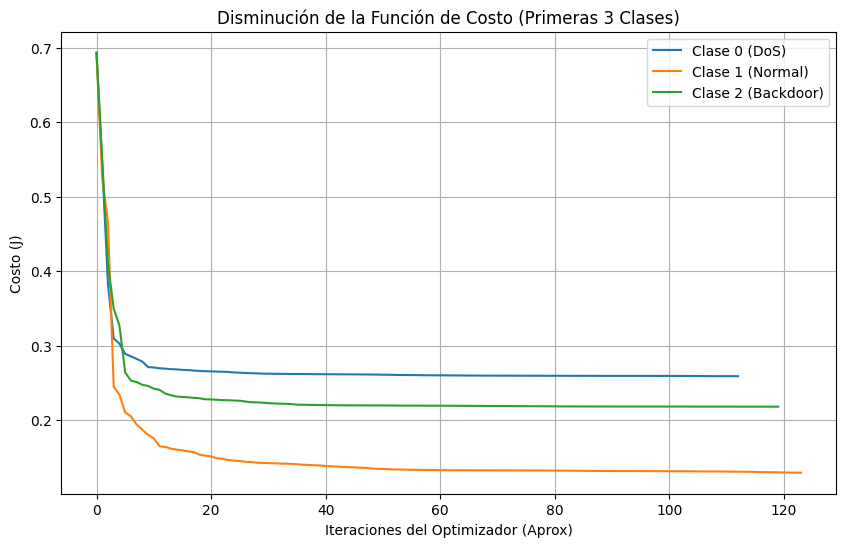

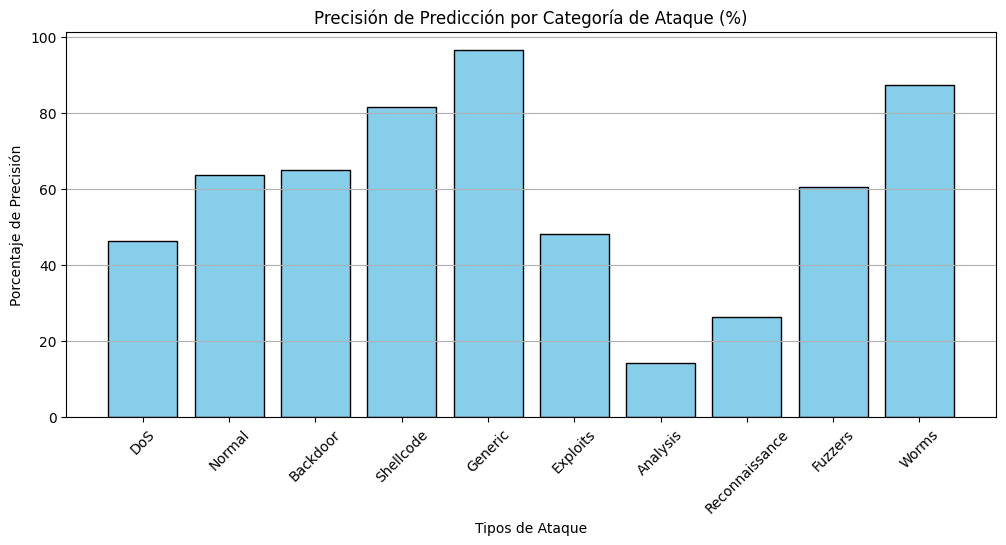

In [7]:
# Función para predecir
def predictOneVsAll(all_theta, X):
    probabilidades = sigmoide(X.dot(all_theta.T))
    # Selecciona la clase con mayor probabilidad
    return np.argmax(probabilidades, axis=1)

# Calculamos precisión en los datos de prueba (El 20% que nunca vio)
predicciones = predictOneVsAll(all_theta, X_test_norm)
precision = np.mean(predicciones == y_test) * 100
print(f"Precisión del Modelo en Datos de Prueba: {precision:.2f}%")

plt.figure(figsize=(10, 6))
# Graficamos el costo de las 3 primeras clases para no saturar la gráfica
for c in range(3):
    plt.plot(historiales[c], label=f'Clase {c} ({etiquetas_unicas[c]})')

plt.title('Disminución de la Función de Costo (Primeras 3 Clases)')
plt.xlabel('Iteraciones del Optimizador (Aprox)')
plt.ylabel('Costo (J)')
plt.legend()
plt.grid(True)
plt.show()

# Calculamos en qué clases se equivocó más y menos
aciertos_por_clase = []
for c in range(num_labels):
    total_clase = np.sum(y_test == c)
    aciertos = np.sum((predicciones == c) & (y_test == c))
    porcentaje = (aciertos / total_clase) * 100 if total_clase > 0 else 0
    aciertos_por_clase.append(porcentaje)

plt.figure(figsize=(12, 5))
plt.bar(etiquetas_unicas, aciertos_por_clase, color='skyblue', edgecolor='black')
plt.title('Precisión de Predicción por Categoría de Ataque (%)')
plt.xlabel('Tipos de Ataque')
plt.ylabel('Porcentaje de Precisión')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()